In [290]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

# Verify the path was added (optional)
print(f"Project root added to sys.path: {project_root}")

Project root added to sys.path: /mnt/c/Users/LENOVO/sandbox/portfolio/geomarketing-coffeshop-makassar


In [291]:
import pandas as pd

from utils.utils import clean_text, lemmatize_tokens, extract_rating

In [292]:
reviews_cust = pd.read_csv('../dataset/reviews_Onkel John\'s Coffee Hasanuddin.csv')

In [293]:
reviews_cust.head()

,nama,reviews,rating
0,ekov_3,"Awalnya penasaran deket hotel kuk ramai sekali dimalam hari.\nSaya coba datang moment breakfast dan mereka sudah buka . Tempatnya nyaman, luas parkiran juga cukup memadai. …",5 bintang
1,Siba Waihi,"Kopi & snack nya enak, tersedia makanan berat, parkir luas, live music nya keren",5 bintang
2,Alvia Fadliana,"Tempatnya sangat nyaman, tenang, relax.\nsy order pizza, rasanya masuk banget di lidahku,\nMinumnya pesen moccacino, sukaaaaaa bangeetttt, rasanya PAS banget🤍🤍🤍 Manisnya dapat, Pahitnya Dapat …",5 bintang
3,Jasmir Aly,Sangat rekomended.\nDan pelayanannya sangat bagus.\nApalagi buat santai.,5 bintang
4,aisah ulfah Syam,Temptnya bagus makanan enak & ada live musiknya bagus,5 bintang


In [294]:
reviews_cust.shape

(239, 3)

**Preprocess Reviews**

In [295]:
reviews_cust.isna().sum()

nama        0
reviews    80
rating      0
dtype: int64

In [296]:
reviews_cust[reviews_cust['reviews'].isna()]

,nama,reviews,rating
118,A M F G M,NaN,4 bintang
151,PIERE PINONTOAN,NaN,5 bintang
152,Adha priyatnadi,NaN,5 bintang
154,Ahya Ahmadan,NaN,5 bintang
155,Kiki Sumarlin,NaN,5 bintang
...,...,...,...
234,Suzy Kandani,NaN,3 bintang
235,Fida Sulystiani,NaN,5 bintang
236,ffajrin karim,NaN,5 bintang
237,haris bayu,NaN,5 bintang


In [297]:
reviews_cust.dropna(inplace=True)

In [298]:
reviews_cust.drop_duplicates(inplace=True, ignore_index=True)

In [299]:
reviews_cust.drop_duplicates(subset=['nama'], inplace=True)
reviews_cust[reviews_cust.duplicated(subset=['nama'])]

,nama,reviews,rating


In [300]:
reviews_cust['rating'] = reviews_cust['rating'].apply(lambda x: extract_rating(x))
reviews_cust['cleaned_reviews'] = reviews_cust['reviews'].apply(lambda x: clean_text(x))
reviews_cust['tokens'] = reviews_cust['cleaned_reviews'].apply(lambda x: x.split()) # tokenization
reviews_cust['lemmatized'] = reviews_cust['tokens'].apply(lambda x: lemmatize_tokens(x))

In [301]:
reviews_cust.head()

,nama,reviews,rating,cleaned_reviews,tokens,lemmatized
0,ekov_3,"Awalnya penasaran deket hotel kuk ramai sekali dimalam hari.\nSaya coba datang moment breakfast dan mereka sudah buka . Tempatnya nyaman, luas parkiran juga cukup memadai. …",5,penasaran deket hotel kuk ramai dimalam coba moment breakfast buka tempatnya nyaman luas parkiran memadai,"[penasaran, deket, hotel, kuk, ramai, dimalam, coba, moment, breakfast, buka, tempatnya, nyaman, luas, parkiran, memadai]",penasaran deket hotel kuk ramai malam coba moment breakfast buka tempat nyaman luas parkir pada
1,Siba Waihi,"Kopi & snack nya enak, tersedia makanan berat, parkir luas, live music nya keren",5,kopi snack enak tersedia makanan berat parkir luas live music keren,"[kopi, snack, enak, tersedia, makanan, berat, parkir, luas, live, music, keren]",kopi snack enak sedia makan berat parkir luas live music keren
2,Alvia Fadliana,"Tempatnya sangat nyaman, tenang, relax.\nsy order pizza, rasanya masuk banget di lidahku,\nMinumnya pesen moccacino, sukaaaaaa bangeetttt, rasanya PAS banget🤍🤍🤍 Manisnya dapat, Pahitnya Dapat …",5,tempatnya nyaman tenang relax sy order pizza masuk lidahku minumnya pesen moccacino sukaaaaaa bangeetttt manisnya pahitnya,"[tempatnya, nyaman, tenang, relax, sy, order, pizza, masuk, lidahku, minumnya, pesen, moccacino, sukaaaaaa, bangeetttt, manisnya, pahitnya]",tempat nyaman tenang relax sy order pizza masuk lidah minum sen moccacino sukaaaaaa bangeetttt manis pahit
3,Jasmir Aly,Sangat rekomended.\nDan pelayanannya sangat bagus.\nApalagi buat santai.,5,rekomended pelayanannya bagus santai,"[rekomended, pelayanannya, bagus, santai]",rekomended layan bagus santai
4,aisah ulfah Syam,Temptnya bagus makanan enak & ada live musiknya bagus,5,temptnya bagus makanan enak live musiknya bagus,"[temptnya, bagus, makanan, enak, live, musiknya, bagus]",temptnya bagus makan enak live musik bagus


In [302]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_cust[reviews_cust['rating'] < 2].iloc[:].get(["nama", "cleaned_reviews", "lemmatized"])

In [303]:
pd.set_option('display.max_colwidth', None)

high_rating = reviews_cust[reviews_cust['rating'] == 5].iloc[:].get(["nama", "cleaned_reviews", "lemmatized"])

In [ ]:
import json

with open("../assets/strings/slangwords.txt") as f:
    data = f.read()

lookp_dict = json.loads(data)

In [305]:
lookp_dict

{'@': 'di',
 'abis': 'habis',
 'ad': 'ada',
 'adlh': 'adalah',
 'afaik': 'as far as i know',
 'ahaha': 'haha',
 'aj': 'saja',
 'ajep ajep': 'dunia gemerlap',
 'ak': 'saya',
 'akika': 'aku',
 'akkoh': 'aku',
 'akuwh': 'aku',
 'alay': 'norak',
 'alow': 'halo',
 'ambilin': 'ambilkan',
 'ancur': 'hancur',
 'anjrit': 'anjing',
 'anter': 'antar',
 'ap2': 'apa apa',
 'apasih': 'apa sih',
 'apes': 'sial',
 'aps': 'apa',
 'aq': 'saya',
 'aquwh': 'aku',
 'asbun': 'asal bunyi',
 'aseekk': 'asyik',
 'asekk': 'asyik',
 'asem': 'asam',
 'aspal': 'asli tetapi palsu',
 'astul': 'asal tulis',
 'ato': 'atau',
 'au ah': 'tidak mau tahu',
 'awak': 'saya',
 'ay': 'sayang',
 'ayank': 'sayang',
 'b4': 'sebelum',
 'bakalan': 'akan',
 'bandes': 'bantuan desa',
 'bangedh': 'banget',
 'banpol': 'bantuan polisi',
 'banpur': 'bantuan tempur',
 'basbang': 'basi',
 'bcanda': 'bercanda',
 'bdg': 'bandung',
 'begajulan': 'nakal',
 'beliin': 'belikan',
 'bencong': 'banci',
 'bentar': 'sebentar',
 'ber3': 'bertiga',
 'b

penasaran deket hotel kuk ramai malam coba moment breakfast buka tempat nyaman luas parkir pada kopi snack enak sedia makan berat parkir luas langsung music keren tempat nyaman tenang relax saya order pizza masuk lidah minum sen moccacino sukaaaaaa bangeetttt manis pahit rekomendasi layan bagus santai temptnya bagus makan enak langsung musik bagus cafe nyaman dan cozy kamu nikmat makan dan minum enak club sandwichx lezat kopi gula aren varian makan sedia dan langsung music favorite wfc kopi enak suasana enak hujan syahdu nonton bareng suka ramai kesana tidak nonton bareng cafe suasana nyaman makan minum variasi ruang ber ac rokok harga sahabat bagus toilet bersih mushola menu rekomendasi cold brew gula aren ke liter ke harga menu relatif jangkau luas nuansa classic wifinya lancar sedia meeting room kumpul kesini suka ambiencenya vintage tempat tenang minum creamy matcha greentea campur nutella puff masya allah nikmat kafe sampean datang layan bagus minum enak enak kopi rekomendasi cari

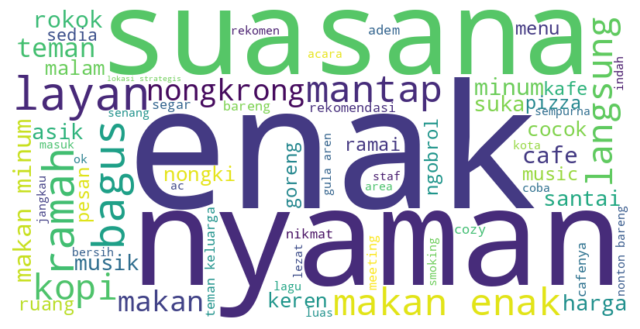

In [306]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword()

text = high_rating['lemmatized'].str.cat(sep=' ')
text = " ".join(lookp_dict.get(ele, ele) for ele in text.split())
print(text)


# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [307]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_cust[reviews_cust['rating'] < 3].iloc[:].get(["nama", "reviews", "cleaned_reviews", "lemmatized"])

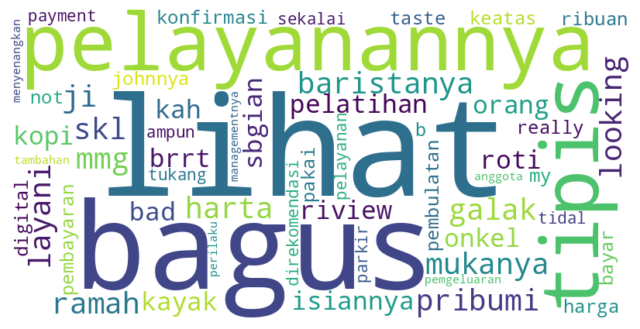

In [308]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword()

text = low_rating['cleaned_reviews'].str.cat(sep=' ')
text = " ".join(lookp_dict.get(ele, ele) for ele in text.split())

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [309]:
low_rating

,nama,reviews,cleaned_reviews,lemmatized
37,salma sisil,"baristanya sebagian mukanya jutek, mmg pribumi dia layani tp yg di liat good looking & good harta ji kl selain itu nda ramah skl, nda bisa di training itu kah pelayanannya? sy juga liat sbgian org2 riview tentang pelayanannya yg bad brrt di situ yg kurang.",baristanya mukanya jutek mmg pribumi layani tp liat good looking good harta ji kl nda ramah skl nda training kah pelayanannya sy liat sbgian org riview pelayanannya bad brrt,baristanya muka jutek mmg pribumi layan tp liat good looking good harta ji kl nda ramah skl nda training kah layan sy liat sbgian org riview layan bad brrt
58,eric tsu,"Roti kaya isiannya sedikit banget, tipis tipis gitu. Kopi onkel johnnya B aja sih, not really my taste.\nSaat pembayaran ada pembulatan (ribuan) harga keatas tanpa konfirmasi, meskipun bayar pakai digital payment.",roti kaya isiannya tipis tipis kopi onkel johnnya b not really my taste pembayaran pembulatan ribuan harga keatas konfirmasi bayar pakai digital payment,roti kaya isi tipis tipis kopi onkel johnnya b not really my taste bayar bulat ribu harga atas konfirmasi bayar pakai digital payment
62,Muh Alif,Pelayanan lama sekalai. Ampun ini tempat. Tidak direkomendasi,pelayanan sekalai ampun direkomendasi,layan sekala ampun rekomendasi
91,Ukka 46,Tidal usah ada tukang parkir. Pemgeluaran tambahan lg,tidal tukang parkir pemgeluaran tambahan lg,tidal tukang parkir pemgeluaran tambah lg
99,Herman Daeng Sijaya,Sangat tdk menyenangkan perilaku anggota managementnya,tdk menyenangkan perilaku anggota managementnya,tdk senang perilaku anggota managementnya


**insight**:
- Terdapat permasalahan di pelayanan barista seperti tidak ramah dan pelayanan yang lambat
- Terdapat tukang parkir yang menyebabkan terjadinya pengeluaran tambahan

In [310]:
reviews_Goodfields = pd.read_csv('../dataset/reviews_Goodfields.csv')

In [311]:
reviews_Goodfields.head()

,nama,reviews,rating
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",1 bintang
1,Yohanes E. W,"Cafe dengan menu yang bermacam sajian yang menarik dan lezat tentunya. Pelayanan yang ramah dan suasana yang nyaman untuk menikmati hidangan sambil ngobrol bersama keluarga atau teman. Tapi waktu penyajiannya cukup memakan waktu, jika sedang ramai untuk 1 menu bisa menunggu 50 menit lebih,",5 bintang
2,Maraden Pangaribuan,"Tempatnya nyaman, pelayanan baik, waktu penyajian makanan perlu ditingkatkan lagi",5 bintang
3,Jefry Malobu,Assalamualaikum selamat datang di lokal guide ini\n\n■ tempat kongkow bersama keluarga bisa …,4 bintang
4,Falah Putra Caesarianto (Putra),"Memutuskan datang ke sini setelah explore google review dan melihat foto-foto serta rating 4.7 dari 1200+ reviews. Setelah 3 hari dinas mendatangi beberapa cafe dan resto lain di Makassar namun mengalami kekecewaan, sehingga berharap bisa …",1 bintang


In [312]:
reviews_Goodfields.shape

(1400, 3)

**Preprocess Reviews**

In [313]:
reviews_Goodfields.isna().sum()

nama         0
reviews    433
rating       0
dtype: int64

In [314]:
reviews_Goodfields[reviews_Goodfields['reviews'].isna()]

,nama,reviews,rating
761,Ling Ling,NaN,5 bintang
869,Febriane Tanumu,NaN,5 bintang
873,Awan Aisyah Rahim,NaN,5 bintang
877,Andi Faradilla Hakim,NaN,4 bintang
878,imam ramdeni,NaN,4 bintang
...,...,...,...
1395,Andi Fatur,NaN,5 bintang
1396,Agus Salim,NaN,5 bintang
1397,marmarmrr,NaN,4 bintang
1398,EKA Arianni,NaN,5 bintang


In [315]:
reviews_Goodfields.dropna(inplace=True)

In [316]:
reviews_Goodfields.drop_duplicates(inplace=True, ignore_index=True)

In [317]:
reviews_Goodfields.drop_duplicates(subset=['nama'], inplace=True)
reviews_Goodfields[reviews_Goodfields.duplicated(subset=['nama'])]

,nama,reviews,rating


In [318]:
reviews_Goodfields['rating'] = reviews_Goodfields['rating'].apply(lambda x: extract_rating(x))
reviews_Goodfields['cleaned_reviews'] = reviews_Goodfields['reviews'].apply(lambda x: clean_text(x))
reviews_Goodfields['tokens'] = reviews_Goodfields['cleaned_reviews'].apply(lambda x: x.split()) # tokenization
reviews_Goodfields['lemmatized'] = reviews_Goodfields['tokens'].apply(lambda x: lemmatize_tokens(x))

In [319]:
reviews_Goodfields.head()

,nama,reviews,rating,cleaned_reviews,tokens,lemmatized
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",1,makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang,"[makanannya, enak, penyajiannya, cepat, sayangnya, pengalaman, bukber, mengecewakan, mobil, digembok, dishub, parkir, badan, jalan, parkir, diarahkan, tukang]",makan enak saji cepat sayang alam bukber kecewa mobil gembok dishub parkir badan jalan parkir arah tukang
1,Yohanes E. W,"Cafe dengan menu yang bermacam sajian yang menarik dan lezat tentunya. Pelayanan yang ramah dan suasana yang nyaman untuk menikmati hidangan sambil ngobrol bersama keluarga atau teman. Tapi waktu penyajiannya cukup memakan waktu, jika sedang ramai untuk 1 menu bisa menunggu 50 menit lebih,",5,cafe menu sajian menarik lezat pelayanan ramah suasana nyaman menikmati hidangan ngobrol keluarga teman penyajiannya memakan ramai menu menunggu menit,"[cafe, menu, sajian, menarik, lezat, pelayanan, ramah, suasana, nyaman, menikmati, hidangan, ngobrol, keluarga, teman, penyajiannya, memakan, ramai, menu, menunggu, menit]",cafe menu saji tarik lezat layan ramah suasana nyaman nikmat hidang ngobrol keluarga teman saji makan ramai menu tunggu menit
2,Maraden Pangaribuan,"Tempatnya nyaman, pelayanan baik, waktu penyajian makanan perlu ditingkatkan lagi",5,tempatnya nyaman pelayanan penyajian makanan ditingkatkan,"[tempatnya, nyaman, pelayanan, penyajian, makanan, ditingkatkan]",tempat nyaman layan saji makan tingkat
3,Jefry Malobu,Assalamualaikum selamat datang di lokal guide ini\n\n■ tempat kongkow bersama keluarga bisa …,4,assalamualaikum selamat lokal guide kongkow keluarga,"[assalamualaikum, selamat, lokal, guide, kongkow, keluarga]",assalamualaikum selamat lokal guide kongkow keluarga
4,Falah Putra Caesarianto (Putra),"Memutuskan datang ke sini setelah explore google review dan melihat foto-foto serta rating 4.7 dari 1200+ reviews. Setelah 3 hari dinas mendatangi beberapa cafe dan resto lain di Makassar namun mengalami kekecewaan, sehingga berharap bisa …",1,memutuskan explore google review foto foto rating reviews dinas cafe resto makassar mengalami kekecewaan berharap,"[memutuskan, explore, google, review, foto, foto, rating, reviews, dinas, cafe, resto, makassar, mengalami, kekecewaan, berharap]",putus explore google review foto foto rating reviews dinas cafe resto makassar alam kecewa harap


In [320]:
pd.set_option('display.max_colwidth', None)

high_rating = reviews_Goodfields[reviews_Goodfields['rating'] == 5].iloc[:].get(["nama", "cleaned_reviews", "lemmatized"])

In [321]:
added_stopwords = ['makan', 'pesan', 'jam', 'layan']

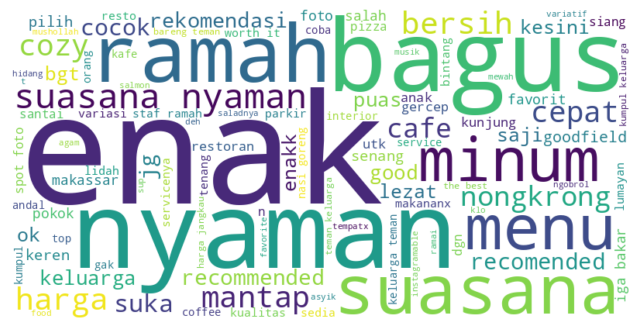

In [322]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword() + added_stopwords

text = high_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [323]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_Goodfields[reviews_Goodfields['rating'] < 3].iloc[:].get(["nama", "reviews", "cleaned_reviews", "lemmatized"])

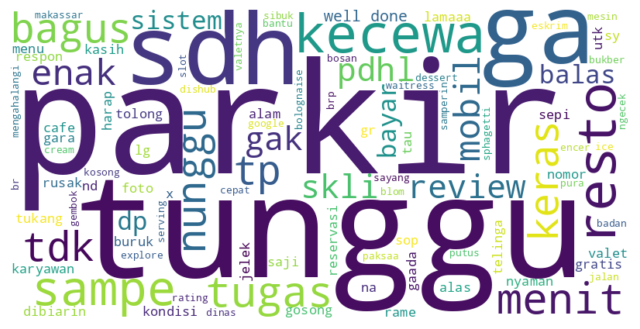

In [324]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword() + added_stopwords

text = low_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [325]:
low_rating[low_rating['reviews'].str.contains('parkir')]

,nama,reviews,cleaned_reviews,lemmatized
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang,makan enak saji cepat sayang alam bukber kecewa mobil gembok dishub parkir badan jalan parkir arah tukang
18,Andre Michael,"Petugas valet sangat tidak membantu, saya menunggu 30 menit lebih di depan parkiran dalam kondisi saya tidak tau kalau tempat nya punya petugas valet Dan ada Mobil parkir mengahalangi slot parkiran yang kosong ,petugas petugas valetnya …",petugas valet membantu menunggu menit parkiran kondisi tau petugas valet mobil parkir mengahalangi slot parkiran kosong petugas petugas valetnya,tugas valet bantu tunggu menit parkir kondisi tau tugas valet mobil parkir mengahalangi slot parkir kosong tugas tugas valetnya
290,Austin Oendy,"Tolong saya jadi malas makan gara gara tukang parkirnya, masa di kasih 3000 maksa minta 5000 sampai mobil saya di kejar"" Padahal posisi parkiran lagi sepi aneh bgt gr gr itu jadi ga bakal saya makan disini lg",tolong malas makan gara gara tukang parkirnya kasih maksa mobil kejar posisi parkiran sepi aneh bgt gr gr ga makan lg,tolong malas makan gara gara tukang parkir kasih maksa mobil kejar posisi parkir sepi aneh bgt gr gr ga makan lg


**insight**:
- Terdapat tukang parkir yang tidak bertanggung jawab

In [326]:
pd.set_option('display.max_colwidth', None)

reviews_Goodfields[reviews_Goodfields['rating'] < 4].iloc[:].get(["nama", "cleaned_reviews"])

,nama,cleaned_reviews
0,jani,makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang
4,Falah Putra Caesarianto (Putra),memutuskan explore google review foto foto rating reviews dinas cafe resto makassar mengalami kekecewaan berharap
9,Hendhy Rahakbauw,pesan menu ice cream utk dessert dibiarin menunggu sampe jam waitress pura sibuk ngecek bosan x samperin mesin eskrim rusak blom paksaa serving encer
18,Andre Michael,petugas valet membantu menunggu menit parkiran kondisi tau petugas valet mobil parkir mengahalangi slot parkiran kosong petugas petugas valetnya
20,Joly Zhang,makanan enak menunggu makanan menit resto sepi pesan sphagetti bolognaise menit br resto ga sop brp serve makanan x kondisi pesan pizza wita sdh
30,Rizky Edy Shafira,bintang bagus review resto dibiarin nunggu makanan sampe jam ga dateng alesan orderan gaada info gaada konfirmasi ga lg wasting time please pay attention
33,Nurul Chairany,suasananya nyaman interior cantik pasta boscaiola pesan berbau kambing khas mual mencium aromanya
51,Yunita,sorry makannya pdhl tempatnya trus lamaaa skli menit utk menu pdhl gak rame meja terisi
52,Mwona Lysa,malam goodfiels menghadapi tamu makanan kluar jam pemesanan lamaaa bangettt ntah karyawan chefnya gimana pointnya mengecewakan
61,afifah rifa,menunggu makanan jam resto lgi tdk rame


In [327]:
reviews_mycoffee = pd.read_csv('../dataset/reviews_MyCoffee.csv')

In [328]:
reviews_mycoffee.head()

,nama,reviews,rating
0,Agung A,Kafe ini menyediakan menu minuman berbasis kopi dengan variasi yg cukup banyak. Makanan ringan yang tersedia juga cukup beragam untuk menemani suasana saat ngopi. Harga makanan dan minuman cukup terjangkau. Indoor roomnya enak buat ngobrol-ngobrol. Outdoor area hanya ada beberapa meja.,5 bintang
1,Nengsi N,"Kemarin tgl 3 feb, aku tuh nongki d sini, trus pas nyampe rumah, aku baru sadar klo atmnya jatuh d sana, tp hebatnya lagi, setelah aku konfirmasi mereka tuh ramah banget bantuin info ke ownernya buat nonton cctv …",5 bintang
2,Michael Chandra,Cafe yang cocok buat nongkrong maupun kerja dan Work from Cafe (WFC). Tempatnya cukup luas dan mejanya lumayan banyak juga. Tersedia jenis kopi yang beragam dan beragam cemilan serta makanan berat yang harganya terjangkau. Buat kerja juga …,5 bintang
3,Helmi Hongi,lokasinya strategis. Banyak hotel dekat kedai kopi. Suasana lun tenang. Saya pesan segelas cappucino dan rice bowl.,4 bintang
4,Joselina Febrin A.Y,"Sebelum buka cabang baru, yaitu terletak di pasar ikan, Saya sudah langganan banget disini. Minuman, makanan itu enakk banget!!! Terus worth it jugaaaa, pelayanan nya ramah sangat, sampai mayan akrab di hafal pula menu ku kyoto latte dan …",5 bintang


In [329]:
reviews_mycoffee.shape

(611, 3)

**Preprocess Reviews**

In [330]:
reviews_mycoffee.isna().sum()

nama         0
reviews    240
rating       0
dtype: int64

In [331]:
reviews_mycoffee[reviews_mycoffee['reviews'].isna()]

,nama,reviews,rating
307,Elizabeth Haryantho,NaN,5 bintang
326,Sherly Wijaya,NaN,5 bintang
337,kuchai thu,NaN,5 bintang
338,adhyah Yusuf,NaN,4 bintang
341,nana oppeng,NaN,5 bintang
...,...,...,...
606,Barista pouring channel training,NaN,5 bintang
607,Nikar Nikah Purnamasari,NaN,5 bintang
608,Hadi Yogianto,NaN,5 bintang
609,Valencia Ciantika,NaN,1 bintang


In [332]:
reviews_mycoffee.dropna(inplace=True)

In [333]:
reviews_mycoffee.drop_duplicates(subset='nama', inplace=True)
reviews_mycoffee[reviews_mycoffee.duplicated(subset='nama')]

,nama,reviews,rating


In [334]:
reviews_mycoffee['rating'] = reviews_mycoffee['rating'].apply(lambda x: extract_rating(x))
reviews_mycoffee['cleaned_reviews'] = reviews_mycoffee['reviews'].apply(lambda x: clean_text(x))
reviews_mycoffee['tokens'] = reviews_mycoffee['cleaned_reviews'].apply(lambda x: x.split()) # tokenization
reviews_mycoffee['lemmatized'] = reviews_mycoffee['tokens'].apply(lambda x: lemmatize_tokens(x))

In [335]:
reviews_mycoffee.head()

,nama,reviews,rating,cleaned_reviews,tokens,lemmatized
0,Agung A,Kafe ini menyediakan menu minuman berbasis kopi dengan variasi yg cukup banyak. Makanan ringan yang tersedia juga cukup beragam untuk menemani suasana saat ngopi. Harga makanan dan minuman cukup terjangkau. Indoor roomnya enak buat ngobrol-ngobrol. Outdoor area hanya ada beberapa meja.,5,kafe menyediakan menu minuman berbasis kopi variasi makanan ringan tersedia beragam menemani suasana ngopi harga makanan minuman terjangkau indoor roomnya enak ngobrol ngobrol outdoor area meja,"[kafe, menyediakan, menu, minuman, berbasis, kopi, variasi, makanan, ringan, tersedia, beragam, menemani, suasana, ngopi, harga, makanan, minuman, terjangkau, indoor, roomnya, enak, ngobrol, ngobrol, outdoor, area, meja]",kafe sedia menu minum basis kopi variasi makan ringan sedia agam teman suasana ngopi harga makan minum jangkau indoor roomnya enak ngobrol ngobrol outdoor area meja
1,Nengsi N,"Kemarin tgl 3 feb, aku tuh nongki d sini, trus pas nyampe rumah, aku baru sadar klo atmnya jatuh d sana, tp hebatnya lagi, setelah aku konfirmasi mereka tuh ramah banget bantuin info ke ownernya buat nonton cctv …",5,kemarin tgl feb tuh nongki d trus nyampe rumah sadar klo atmnya jatuh d tp hebatnya konfirmasi tuh ramah bantuin info ownernya nonton cctv,"[kemarin, tgl, feb, tuh, nongki, d, trus, nyampe, rumah, sadar, klo, atmnya, jatuh, d, tp, hebatnya, konfirmasi, tuh, ramah, bantuin, info, ownernya, nonton, cctv]",kemarin tgl feb tuh nongki d trus nyampe rumah sadar klo atmnya jatuh d tp hebat konfirmasi tuh ramah bantuin info ownernya nonton cctv
2,Michael Chandra,Cafe yang cocok buat nongkrong maupun kerja dan Work from Cafe (WFC). Tempatnya cukup luas dan mejanya lumayan banyak juga. Tersedia jenis kopi yang beragam dan beragam cemilan serta makanan berat yang harganya terjangkau. Buat kerja juga …,5,cafe cocok nongkrong kerja work from cafe wfc tempatnya luas mejanya lumayan tersedia jenis kopi beragam beragam cemilan makanan berat harganya terjangkau kerja,"[cafe, cocok, nongkrong, kerja, work, from, cafe, wfc, tempatnya, luas, mejanya, lumayan, tersedia, jenis, kopi, beragam, beragam, cemilan, makanan, berat, harganya, terjangkau, kerja]",cafe cocok nongkrong kerja work from cafe wfc tempat luas meja lumayan sedia jenis kopi agam agam cemilan makan berat harga jangkau kerja
3,Helmi Hongi,lokasinya strategis. Banyak hotel dekat kedai kopi. Suasana lun tenang. Saya pesan segelas cappucino dan rice bowl.,4,lokasinya strategis hotel kedai kopi suasana lun tenang pesan segelas cappucino rice bowl,"[lokasinya, strategis, hotel, kedai, kopi, suasana, lun, tenang, pesan, segelas, cappucino, rice, bowl]",lokasi strategis hotel kedai kopi suasana lun tenang pesan gelas cappucino rice bowl
4,Joselina Febrin A.Y,"Sebelum buka cabang baru, yaitu terletak di pasar ikan, Saya sudah langganan banget disini. Minuman, makanan itu enakk banget!!! Terus worth it jugaaaa, pelayanan nya ramah sangat, sampai mayan akrab di hafal pula menu ku kyoto latte dan …",5,buka cabang terletak pasar ikan langganan minuman makanan enakk worth it jugaaaa pelayanan ramah mayan akrab hafal menu ku kyoto latte,"[buka, cabang, terletak, pasar, ikan, langganan, minuman, makanan, enakk, worth, it, jugaaaa, pelayanan, ramah, mayan, akrab, hafal, menu, ku, kyoto, latte]",buka cabang letak pasar ikan langgan minum makan enakk worth it jugaaaa layan ramah mayan akrab hafal menu ku kyoto latte


In [336]:
pd.set_option('display.max_colwidth', None)

low_rating

,nama,reviews,cleaned_reviews,lemmatized
0,jani,"Makanannya enak dan penyajiannya cukup cepat. Namun sayangnya pengalaman kami setelah bukber di sini sangat mengecewakan. Mobil kami digembok Dishub karena parkir di badan jalan, padahal kami parkir di situ karena diarahkan oleh tukang …",makanannya enak penyajiannya cepat sayangnya pengalaman bukber mengecewakan mobil digembok dishub parkir badan jalan parkir diarahkan tukang,makan enak saji cepat sayang alam bukber kecewa mobil gembok dishub parkir badan jalan parkir arah tukang
4,Falah Putra Caesarianto (Putra),"Memutuskan datang ke sini setelah explore google review dan melihat foto-foto serta rating 4.7 dari 1200+ reviews. Setelah 3 hari dinas mendatangi beberapa cafe dan resto lain di Makassar namun mengalami kekecewaan, sehingga berharap bisa …",memutuskan explore google review foto foto rating reviews dinas cafe resto makassar mengalami kekecewaan berharap,putus explore google review foto foto rating reviews dinas cafe resto makassar alam kecewa harap
9,Hendhy Rahakbauw,"Pesan menu ice cream utk dessert, dibiarin menunggu sampe 1 jam lebih, semua waitress tiap ditanya pura2 sibuk ngecek. Bosan tanya 2-3x saya samperin, ternyata mesin eskrim sepertinya rusak/blom siap. Mau paksaa serving dalam keadaan encer. …",pesan menu ice cream utk dessert dibiarin menunggu sampe jam waitress pura sibuk ngecek bosan x samperin mesin eskrim rusak blom paksaa serving encer,pesan menu ice cream utk dessert dibiarin tunggu sampe jam waitress pura sibuk ngecek bosan x samperin mesin eskrim rusak blom paksaa serving encer
18,Andre Michael,"Petugas valet sangat tidak membantu, saya menunggu 30 menit lebih di depan parkiran dalam kondisi saya tidak tau kalau tempat nya punya petugas valet Dan ada Mobil parkir mengahalangi slot parkiran yang kosong ,petugas petugas valetnya …",petugas valet membantu menunggu menit parkiran kondisi tau petugas valet mobil parkir mengahalangi slot parkiran kosong petugas petugas valetnya,tugas valet bantu tunggu menit parkir kondisi tau tugas valet mobil parkir mengahalangi slot parkir kosong tugas tugas valetnya
20,Joly Zhang,"Makanan enak, tapi untuk menunggu makanan bisa di atas 30 menit dengan keadaan resto sepi. Pesan sphagetti bolognaise 40 menit br jadi. Ini resto ga punya ya SOP brp lama serve makanan? 2x dapat kondisi begini. Pesan pizza 18:20 wita sdh …",makanan enak menunggu makanan menit resto sepi pesan sphagetti bolognaise menit br resto ga sop brp serve makanan x kondisi pesan pizza wita sdh,makan enak tunggu makan menit resto sepi pesan sphagetti bolognaise menit br resto ga sop brp serve makan x kondisi pesan pizza wita sdh
30,Rizky Edy Shafira,"Bahkan bintang 1 terlalu bagus buat review resto ini. Dibiarin nunggu makanan yg sampe 1 jam lebih ga dateng, alesan orderan banyak, gaada info di awal, gaada konfirmasi, tiap ditanya ga balik lg, wasting time. Please pay attention buat …",bintang bagus review resto dibiarin nunggu makanan sampe jam ga dateng alesan orderan gaada info gaada konfirmasi ga lg wasting time please pay attention,bintang bagus review resto dibiarin nunggu makan sampe jam ga dateng alesan order gaada info gaada konfirmasi ga lg wasting time please pay attention
33,Nurul Chairany,Suasananya nyaman dengan interior yang cantik. Tapi pasta boscaiola yang kami pesan berbau kambing yang khas dan membuat mual tiap mencium aromanya.,suasananya nyaman interior cantik pasta boscaiola pesan berbau kambing khas mual mencium aromanya,suasana nyaman interior cantik pasta boscaiola pesan bau kambing khas mual cium aroma
51,Yunita,Sorry makannya terlalu biasa rasanya pdhl tempatnya oke banget. Trus lamaaa skli 40 menit utk 1 menu pdhl gak rame hanya 1 meja terisi,sorry makannya pdhl tempatnya trus lamaaa skli menit utk menu pdhl gak rame meja terisi,sorry makan pdhl tempat trus lamaaa skli menit utk menu pdhl gak rame meja isi
52,Mwona Lysa,"Malam ini goodfiels tidak siap menghadapi tamu yang banyak, alhasil makanan kluar 1 jam setelah pemesan

In [337]:
low_rating.shape

(37, 4)

In [338]:
added_stopwords = ['makan', 'pesan', 'jam', 'layan']

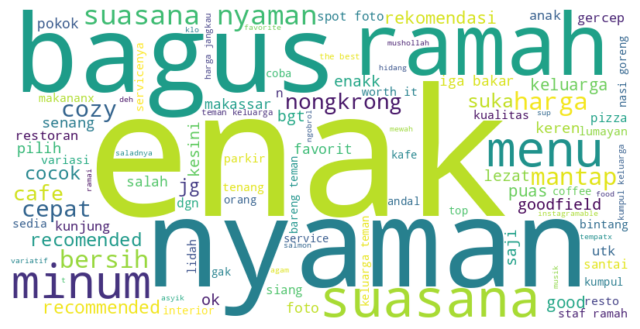

In [339]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword() + added_stopwords

text = high_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [340]:
pd.set_option('display.max_colwidth', None)

low_rating = reviews_mycoffee[reviews_mycoffee['rating'] < 3].iloc[:].get(["nama", "reviews", "cleaned_reviews", "lemmatized"])

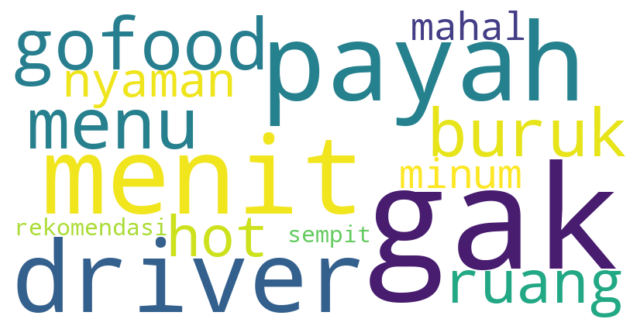

In [341]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nlp_id.stopword import StopWord

stopwords = StopWord()
stopwords_list = stopwords.get_stopword() + added_stopwords

text = low_rating['lemmatized'].str.cat(sep=' ')

# Generate the word cloud object
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_list,
    max_words=100, # Limit the number of words
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [342]:
low_rating[low_rating['lemmatized'].str.contains('sempit')]

,nama,reviews,cleaned_reviews,lemmatized
237,Maxi Teja,Tempat Terlalu Sempit,sempit,sempit


In [343]:
pd.set_option('display.max_colwidth', None)

low_rating

,nama,reviews,cleaned_reviews,lemmatized
44,Andi Besse,"Pelayanan sangat lama, pesan makanan 20 menit belum jadi...payah pelayanan nya 🤦 …",pelayanan pesan makanan menit payah pelayanan,layan pesan makan menit payah layan
126,إسراء حسن,"Pesan lewat driver gofood, makanannya kurang 1 menu..pelayanan buruk",pesan driver gofood makanannya menu pelayanan buruk,pesan driver gofood makan menu layan buruk
147,Azzam Pranaja,"Ruangan hot, gak nyaman, minumannya pun mahal. Gak rekomendasi",ruangan hot gak nyaman minumannya mahal gak rekomendasi,ruang hot gak nyaman minum mahal gak rekomendasi
161,Farhan Mujahid (Abu Mubarok),Biasa saja,,
237,Maxi Teja,Tempat Terlalu Sempit,sempit,sempit
